This notebook performs spatial hotspot analysis of predictive multiplicity using Moran’s I and Local Moran (LISA).

**Inputs (precomputed)**

* Rashomon predictions on test set

* Observation-wise prediction variance

* Test feature space

## 1. Imports and paths

In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import analysis module
# In Jupyter, cwd is usually the project root, but we check both
project_root = Path.cwd()
if not (project_root / 'analysis').exists():
    # If analysis/ not in cwd, try parent directory
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.spatial import (
    build_knn_graph,
    moran_global,
    lisa_local,
    extract_hh_components,
)

In [2]:
# Adjust this path to the experiment you want to analyze
# Path is relative to notebook location (notebooks/ directory)
BASE_PATH = Path("../results/compas/seed=42_eps=0.01")
assert BASE_PATH.exists(), f"Result directory not found: {BASE_PATH.absolute()}"

## 2. Load saved artifacts

In [3]:
P = np.load(BASE_PATH / "P_test.npy")
metrics = np.load(BASE_PATH / "metrics.npz")
X_test = pd.read_csv(BASE_PATH / "X_test.csv")

In [4]:
v = metrics["variance"]

## 3. Build spatial graph (feature space)

In [5]:
k = 10  # number of nearest neighbors
W = build_knn_graph(X_test, k=k)

In [6]:
print("Adjacency matrix shape:", W.shape)

Adjacency matrix shape: (1443, 1443)


## 4. Global Moran’s I

In [7]:
moran_res = moran_global(v, W)
moran_res

{'I': 0.4424831027128618, 'p_value': 0.0}

In [8]:
if moran_res['p_value'] < 0.05:
    print("✔ Significant spatial autocorrelation detected")
else:
    print("✖ No significant spatial autocorrelation detected")

✔ Significant spatial autocorrelation detected


## 5. Local Moran / LISA

In [9]:
lisa = lisa_local(v, W)
lisa.head()

,Ii,p_value,cluster
0,0.208376,0.101101,NS
1,0.144475,0.093093,NS
2,0.093580,0.245245,NS
3,0.034187,0.588589,NS
4,0.040566,0.448448,NS


In [10]:
lisa['cluster'].value_counts()

cluster
NS    1396
HH      46
LH       1
Name: count, dtype: int64

## 6. Hotspot (HH) visualization

In [11]:
HH_mask = lisa['cluster'] == 'HH'

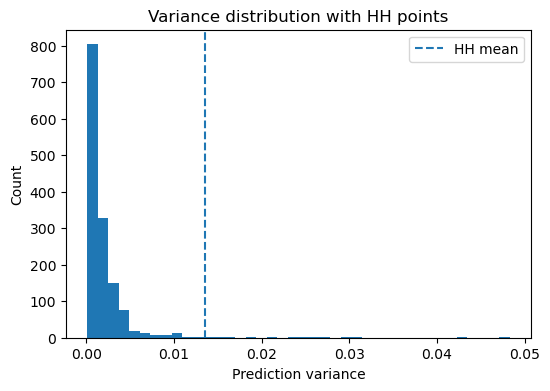

In [12]:
plt.figure(figsize=(6, 4))
plt.hist(v, bins=40)
plt.axvline(v[HH_mask].mean(), linestyle='--', label='HH mean')
plt.xlabel('Prediction variance')
plt.ylabel('Count')
plt.legend()
plt.title('Variance distribution with HH points')
plt.show()

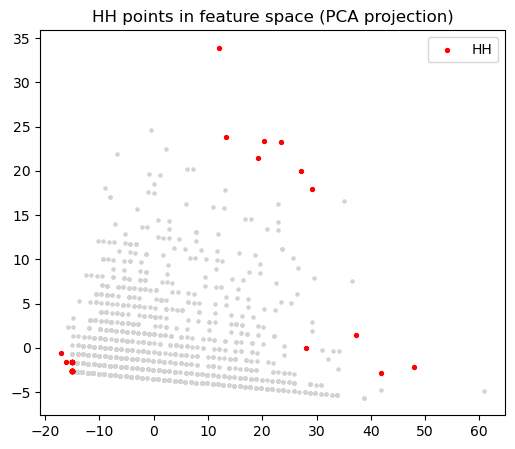

In [13]:
# 2D projection for visualization only
from sklearn.decomposition import PCA

# Select only numeric columns for PCA (same as used in kNN graph)
X_test_numeric = X_test.select_dtypes(include=[np.number])
X_proj = PCA(n_components=2).fit_transform(X_test_numeric)

plt.figure(figsize=(6, 5))
plt.scatter(X_proj[:, 0], X_proj[:, 1], c='lightgray', s=5)
plt.scatter(X_proj[HH_mask, 0], X_proj[HH_mask, 1], c='red', s=8, label='HH')
plt.legend()
plt.title('HH points in feature space (PCA projection)')
plt.show()

## 7. Connected HH components

In [14]:
comp_id, components = extract_hh_components(lisa, W, min_size=5)
print("Number of HH components:", len(components))

Number of HH components: 3


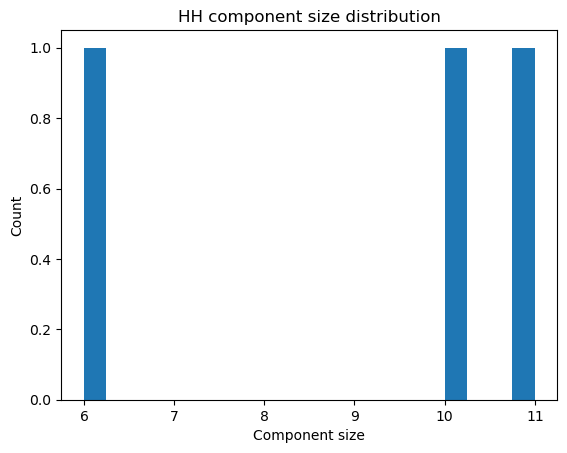

In [15]:
sizes = [len(v) for v in components.values()]
plt.hist(sizes, bins=20)
plt.xlabel('Component size')
plt.ylabel('Count')
plt.title('HH component size distribution')
plt.show()

## 8. Inspect a single hotspot region

In [16]:
# Pick the largest component
largest = max(components.items(), key=lambda x: len(x[1]))
cid, idx = largest

X_hh = X_test.iloc[idx]
v_hh = v[idx]

In [17]:
X_hh.describe()

,age,priors_count
count,11.000000,11.0
mean,19.909091,1.0
std,0.301511,0.0
min,19.000000,1.0
25%,20.000000,1.0
50%,20.000000,1.0
75%,20.000000,1.0
max,20.000000,1.0


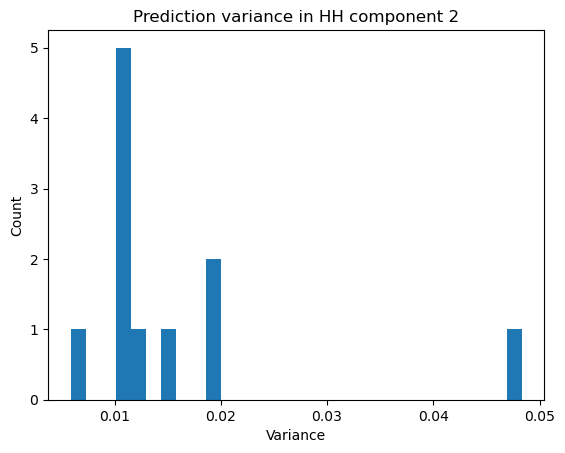

In [18]:
plt.hist(v_hh, bins=30)
plt.title(f'Prediction variance in HH component {cid}')
plt.xlabel('Variance')
plt.ylabel('Count')
plt.show()